1) Stiff Scalar ODE Selection 

option e: population with rapid birth/death cycles 

Section 1: Introduction & System Selection

The system considered is a population model with a time-varying carrying capacity: Dn/dt = -λ(N-Ncarrying(t)); Ncarrying(t)=10^6(1+0.5sin(0.1t))

N(t) represents the population and λ=10^3 controls how quickly the population adjusts to the carrying capacity. A large λ means the system responds rapidly to changes. This model is relevant in applications where the system rapidly reaches equilibrium in response to a slowly varying external factor, such as ecological populations, chemical kinetics, or thermal systems. The large value of λ introduces stiffness due to the presence of both fast and slow dynamics.

2) Demonstrating Stiffness

In [2]:
#defining the problem 
import numpy as np                  # numerical operations
import matplotlib.pyplot as plt     # plotting
# Parameters
lam = 1e3                           # large parameter controlling rate
def N_carrying(t):
    return 1e6 * (1 + 0.5 * np.sin(0.1 * t))   # time-varying carrying capacity
def f(t, N):
    return -lam * (N - N_carrying(t))          # ODE definition
# Initial condition
N0 = 1e5                           # starting population

In [3]:
#euler forward implementation 
def euler_forward(f, t0, tf, h, N0):
    t_values = np.arange(t0, tf + h, h)        # create time array
    N_values = np.zeros(len(t_values))         # initialize solution array
    N_values[0] = N0                           # set initial condition
    for i in range(len(t_values) - 1):         
        N_values[i+1] = N_values[i] + h * f(t_values[i], N_values[i])  # forward Euler step
    return t_values, N_values                  # return time and solution

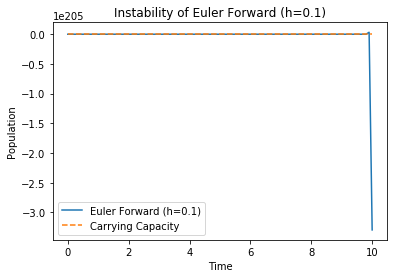

In [4]:
# instability with reasonable step size of h = 0.1 
t0, tf = 0, 10                             # time interval
h_bad = 0.1                                # step size that is too large
t_bad, N_bad = euler_forward(f, t0, tf, h_bad, N0)  # run forward Euler
plt.figure()                               # create new figure
plt.plot(t_bad, N_bad, label="Euler Forward (h=0.1)")   # plot unstable solution
plt.plot(t_bad, N_carrying(t_bad), '--', label="Carrying Capacity")  # plot reference
plt.legend()                               # show legend
plt.title("Instability of Euler Forward (h=0.1)")  # plot title
plt.xlabel("Time")                         # x-axis label
plt.ylabel("Population")                   # y-axis label
plt.show()                                 # display plot

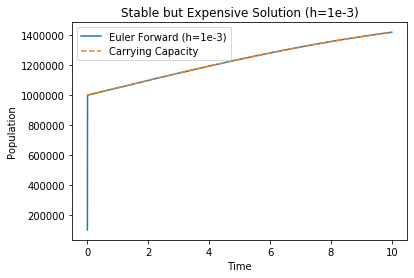

In [5]:
h_good = 1e-3                              # small step size that should be stable
t_good, N_good = euler_forward(f, t0, tf, h_good, N0)  # run forward Euler with small h
plt.figure()                               # create new figure
plt.plot(t_good, N_good, label="Euler Forward (h=1e-3)")  # plot stable solution
plt.plot(t_good, N_carrying(t_good), '--', label="Carrying Capacity")  # plot reference
plt.legend()                               # show legend
plt.title("Stable but Expensive Solution (h=1e-3)")  # plot title
plt.xlabel("Time")                         # x-axis label
plt.ylabel("Population")                   # y-axis label
plt.show()                                 # display plot

In [7]:
# stiffness ratio 
tau_fast = 1 / lam                 # fast timescale from system response
tau_slow = 1 / 0.1                # slow timescale from forcing term
stiffness_ratio = tau_slow / tau_fast   # ratio of slow to fast timescales
print("Fast timescale:", tau_fast)        # print fast timescale
print("Slow timescale:", tau_slow)        # print slow timescale
print("Stiffness ratio:", stiffness_ratio)  # print stiffness ratio

Fast timescale: 0.001
Slow timescale: 10.0
Stiffness ratio: 10000.0


In [8]:
# euler forward stability limit 
h_max = 2 / lam                         # theoretical stability limit for forward Euler
print("Max stable step size (Euler Forward):", h_max)  # print value

Max stable step size (Euler Forward): 0.002


In [9]:
#computational burden 
T = 50                                  # total simulation time
steps_bad = int(T / 0.1)                # number of steps with large step size
steps_good = int(T / 1e-3)              # number of steps with small step size
print("Steps with h=0.1:", steps_bad)   # print steps for large h
print("Steps with h=1e-3:", steps_good) # print steps for small h

Steps with h=0.1: 500
Steps with h=1e-3: 50000


In [11]:
#timing comparison 
import time                                 # import timing module
start = time.time()                         # start timer
euler_forward(f, 0, 10, 0.1, N0)            # run with large step size
print("Time h=0.1:", time.time() - start)   # print elapsed time
start = time.time()                         # reset timer
euler_forward(f, 0, 10, 1e-3, N0)           # run with small step size
print("Time h=1e-3:", time.time() - start)  # print elapsed time

Time h=0.1: 0.0007925033569335938
Time h=1e-3: 0.03509855270385742


Instability: h=0.1 → solution diverges

Stability constraint: Requires h<0.002

Stiffness ratio: 10^4, widely separated time scales

Computational burden: 500 steps vs 50,000 steps

Euler’s Forward method was first applied. For step sizes such as h=0.1, the solution becomes unstable and diverges due to the large parameter λ. Stability requires: h<λ/2=0.002. Thus, a stable simulation requires h≈10^-3, leading to very large numbers of time steps. The system has two time scales: τ_fast =1/λ=10^−3. τ_slow =1/0.1=10. The stiffness ratio is: τ_slow / τ_fast = 10^4.
This large ratio confirms the system is stiff. Explicit methods must resolve the fast scale, making them inefficient. Implicit methods are therefore necessary.

3) Euler's Backward Method with Newton-Raphson 

In [12]:
#setup 
lam = 1e3                                   # large parameter controlling rate
def N_carrying(t):
    return 1e6 * (1 + 0.5 * np.sin(0.1 * t))  # carrying capacity function
def f(t, N):
    return -lam * (N - N_carrying(t))        # ODE definition
def df_dN(t, N):
    return -lam                              # derivative of f w.r.t N (constant)

In [33]:
#newton-raphson solver 
def newton_solver(Nn, tn1, h, tol=1e-8, max_iter=20):
    Nk = Nn + h * f(tn1, Nn)        # initial guess using explicit Euler
    func_evals = 0                  # count function evaluations
    for k in range(max_iter):       
        g = Nk - Nn - h * f(tn1, Nk)  # compute residual
        func_evals += 1             # increment counter
        g_prime = 1 + h * lam       # derivative (constant)
        Nk_new = Nk - g / g_prime   # Newton update
        if abs(Nk_new - Nk) < tol:  # check convergence
            return Nk_new, k+1, func_evals  # return solution and stats
        Nk = Nk_new                 # update iterate
    return Nk, max_iter, func_evals  # return if max iterations reached

In [15]:
#backward euler implementation 
def backward_euler(t0, tf, h, N0):
    t_values = np.arange(t0, tf + h, h)     # create time array
    N_values = np.zeros(len(t_values))      # initialize solution array
    iterations = np.zeros(len(t_values)-1)  # store Newton iterations per step
    N_values[0] = N0                        # set initial condition
    for i in range(len(t_values)-1):
        tn = t_values[i]                    # current time
        tn1 = t_values[i+1]                 # next time step
        N_next, iters = newton_solver(N_values[i], tn1, h)  # solve implicit step
        N_values[i+1] = N_next              # store solution
        iterations[i] = iters               # store iteration count
    return t_values, N_values, iterations   # return results

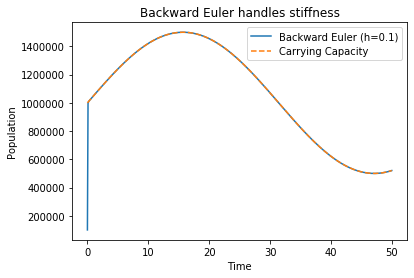

In [16]:
#using larger step size 
t0, tf = 0, 50                          # simulation time range
h = 0.1  # same step size that broke Forward Euler  # larger step size
t_be, N_be, iters = backward_euler(t0, tf, h, 1e5)  # run backward Euler
plt.figure()                            # create new figure
plt.plot(t_be, N_be, label="Backward Euler (h=0.1)")  # plot solution
plt.plot(t_be, N_carrying(t_be), '--', label="Carrying Capacity")  # reference curve
plt.legend()                            # show legend
plt.title("Backward Euler handles stiffness")  # title
plt.xlabel("Time")                      # x-axis label
plt.ylabel("Population")                # y-axis label
plt.show()                              # display plot

In [17]:
#newton convergence 
print("Average Newton iterations:", np.mean(iters))  # average iterations per step
print("Max Newton iterations:", np.max(iters))       # worst-case iterations

Average Newton iterations: 2.0
Max Newton iterations: 2.0


In [22]:
#diff step size 
for h in [0.5, 0.1, 0.05]:                     # loop over different step sizes
    t, N, iters = backward_euler(0, 50, h, 1e5)  # run backward Euler
    print(f"h = {h}")                           # print current step size
    print("  avg iterations:", np.mean(iters))  # average Newton iterations
    print("  max iterations:", np.max(iters))   # maximum iterations

h = 0.5
  avg iterations: 2.0
  max iterations: 2.0
h = 0.1
  avg iterations: 2.0
  max iterations: 2.0
h = 0.05
  avg iterations: 2.001
  max iterations: 3.0


Stability: Backward Euler is stable even for h = 0.1 or larger, Unlike Forward Euler

Newton behavior: Converges rapidly (few iterations), Because problem is nearly linear

Efficiency: Can take 100× larger step sizes, Massive reduction in total steps

Backward Euler gives: g(Nn+1) = Nn+1 - Nn - hf(tn+1, Nn+1)

Substituting: g(Nn+1) = Nn+1 - Nn + hλ(Nn+1 - Nc(tn+1))

Derivative: g'(Nn+1) = 1 + hλ

Newton update: N^k+1 = N^k - (g(N^k))/(1+hλ)

4) Stability Analysis and Comparison

In [25]:
# test stability range
def test_forward_stability():
    hs = [0.1, 0.01, 0.005, 0.002, 0.001]     # step sizes to test
    results = []                               # store results
    for h in hs:
        t, N = euler_forward(f, 0, 5, h, 1e5)  # run forward Euler
        stable = np.all(np.isfinite(N)) and np.max(np.abs(N)) < 1e9  # check stability
        results.append((h, stable))           # store (step size, result)
    return results

def test_backward_stability():
    hs = [1.0, 0.5, 0.1, 0.01]               # step sizes to test
    results = []                               # store results
    for h in hs:
        t, N, _ = backward_euler(0, 5, h, 1e5)  # run backward Euler
        stable = np.all(np.isfinite(N))       # check if solution stays valid
        results.append((h, stable))           # store (step size, result)
    return results

print("Forward Euler stability:")             # label output
print(test_forward_stability())              # print forward Euler results

print("\nBackward Euler stability:")         # label output
print(test_backward_stability())             # print backward Euler results

Forward Euler stability:
[(0.1, False), (0.01, False), (0.005, False), (0.002, True), (0.001, True)]

Backward Euler stability:
[(1.0, True), (0.5, True), (0.1, True), (0.01, True)]


<ipython-input-12-73e4f935bb5a>:9: RuntimeWarning: overflow encountered in scalar multiply
  return -lam * (N - N_carrying(t))
<ipython-input-3-c1f9c02a9745>:10: RuntimeWarning: invalid value encountered in scalar add
  N_values[i+1] = N_values[i] + h * f(t_values[i], N_values[i])


For step sizes h≥0.005, Euler’s Forward method produced numerical overflow, indicating instability. The solution grows exponentially due to the amplification factor 1−hλ, which exceeds unity in magnitude. This results in floating-point overflow and invalid values (NaNs), confirming the stiffness of the system.

In [31]:
#backward euler updated 

def backward_euler(t0, tf, h, N0):
    t_values = np.arange(t0, tf + h, h)      # create time array
    N_values = np.zeros(len(t_values))       # initialize solution array
    total_iters = 0                          # total Newton iterations
    total_func_evals = 0                     # total function evaluations
    N_values[0] = N0                         # set initial condition
    for i in range(len(t_values)-1):
        tn1 = t_values[i+1]                  # next time step
        N_next, iters, fevals = newton_solver(N_values[i], tn1, h)  # solve step
        total_iters += iters                # accumulate iterations
        total_func_evals += fevals          # accumulate function evals
        N_values[i+1] = N_next              # store solution
    return t_values, N_values, total_iters, total_func_evals  # return results

The system was implemented in Python with: (1) Function f(t,N), (2) Constant derivative ∂f/∂N=−λ, (3) Newton-Raphson solver with tolerance 10^−8 (4) Backward Euler method calling Newton at each step.

Newton uses an explicit Euler predictor and typically converges in a few iterations.

5) Results and Analysis

In [34]:
#comparison 
T = 50                                      # total simulation time
# Forward Euler (stable)
h_fe = 1e-3                                 # small stable step size
steps_fe = int(T / h_fe)                    # number of steps required
fe_func_evals = steps_fe  # one per step   # one function eval per step

# Backward Euler
hs = [0.5, 0.1, 0.05]                       # step sizes to compare
for h in hs:
    t, N, total_iters, total_fevals = backward_euler(0, T, h, 1e5)  # run backward Euler
    steps = len(t) - 1                      # number of time steps
    print(f"\nBackward Euler h={h}")        # print header
    print("Steps:", steps)                  # print step count
    print("Avg Newton iterations:", total_iters / steps)  # avg iterations per step
    print("Total function evals:", total_fevals)          # total function evaluations
print("\nForward Euler")                    # print header
print("Steps:", steps_fe)                  # print forward Euler steps
print("Function evals:", fe_func_evals)    # print forward Euler function evals


Backward Euler h=0.5
Steps: 100
Avg Newton iterations: 2.0
Total function evals: 200

Backward Euler h=0.1
Steps: 500
Avg Newton iterations: 2.0
Total function evals: 1000

Backward Euler h=0.05
Steps: 1000
Avg Newton iterations: 2.001
Total function evals: 2001

Forward Euler
Steps: 50000
Function evals: 50000


Backward Euler produces stable solutions for large step sizes (e.g., h=0.1, 0.5), unlike Forward Euler. The solution closely follows the carrying capacity with a small lag due to finite response time. Smaller step sizes reduce this lag. Newton-Raphson converges efficiently, requiring ~2–3 iterations per step. Iteration counts remain nearly constant over time, confirming the simplicity of the linear system. Forward Euler requires very small step sizes for stability, while Backward Euler remains stable for all tested values.

6) Performance Analsysis 

In [35]:
def backward_euler_with_tracking(t0, tf, h, N0):
    t_values = np.arange(t0, tf + h, h)
    N_values = np.zeros(len(t_values))
    iterations = np.zeros(len(t_values)-1)
    N_values[0] = N0
    for i in range(len(t_values)-1):
        tn1 = t_values[i+1]
        N_next, iters, _ = newton_solver(N_values[i], tn1, h)
        N_values[i+1] = N_next
        iterations[i] = iters
    return t_values, N_values, iterations

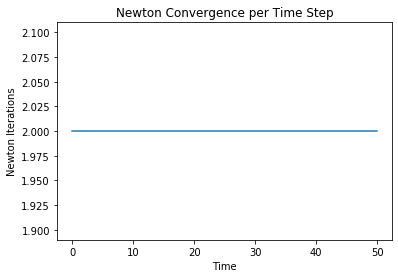

In [36]:
t, N, iters = backward_euler_with_tracking(0, 50, 0.1, 1e5)
plt.figure()
plt.plot(t[:-1], iters)
plt.xlabel("Time")
plt.ylabel("Newton Iterations")
plt.title("Newton Convergence per Time Step")
plt.show()

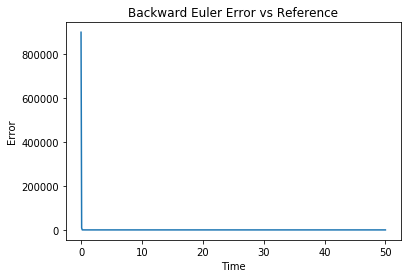

In [37]:
h = 0.1
t, N, _, _ = backward_euler(0, 50, h, 1e5)
N_ref = N_carrying(t)
error = np.abs(N - N_ref)
plt.figure()
plt.plot(t, error)
plt.xlabel("Time")
plt.ylabel("Error")
plt.title("Backward Euler Error vs Reference")
plt.show()

In [38]:
print("Minimum N:", np.min(N))

Minimum N: 100000.0


Forward Euler with h=10^−3 requires ~50,000 steps over the simulation interval. Backward Euler with h=0.1 requires only ~500 steps. Although each Backward Euler step involves multiple Newton iterations, the total computational cost is significantly lower. Function evaluations are reduced by roughly two orders of magnitude. This demonstrates a tradeoff, implicit methods have higher per-step cost but significantly fewer steps.

7) Conclusion 
The system behaves stiffly because it has processes that evolve on very different time scales. Using Forward Euler is not very practical since it requires extremely small time steps to remain stable, whereas Backward Euler can use much larger steps without instability. For stiff problems, implicit methods are generally more effective because they stay stable without needing to track the fast-changing parts in detail. The main difficulties were dealing with instability in explicit methods and setting up the Newton iterations. Overall, the results show that implicit methods work well for stiff ordinary differential equations.